<a href="https://colab.research.google.com/github/HarshRaj3112007/100-Days-of-ML/blob/main/MNIST_Recognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

digit_recognizer_path = kagglehub.competition_download('digit-recognizer')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [ ]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [ ]:
print(df.shape)
df.sample()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
39530,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

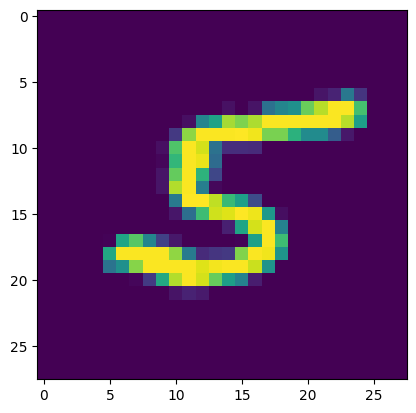

In [ ]:
plt.imshow(df.iloc[12345,1:].values.reshape(28,28))
plt.show()

In [ ]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [ ]:
start = time.time()
y_pred = knn.predict(X_test)
print(time.time()-start)

10.4925217628479


In [ ]:
accuracy_score(y_pred,Y_test)

0.9675

In [ ]:
pca = PCA(n_components=100)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [ ]:
kn = KNeighborsClassifier()
kn.fit(X_train_trf,Y_train)


KNeighborsClassifier()

In [ ]:
start = time.time()
y_pred_n = knn.predict(X_test)
print(time.time()-start)

10.337371587753296


In [ ]:
accuracy_score(y_pred_n,Y_test)

0.9675

In [ ]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_trf,Y_train)

    y_pred = knn.predict(X_test_trf)

    print(accuracy_score(Y_test,y_pred))

0.2675
0.41845238095238096
0.48714285714285716
0.6309523809523809
0.7391666666666666
0.8221428571428572
0.8708333333333333
0.8982142857142857
0.9151190476190476
0.9269047619047619
0.9355952380952381
0.9434523809523809
0.9526190476190476
0.955595238095238
0.9572619047619048
0.9625
0.9629761904761904
0.9653571428571428
0.9673809523809523
0.9676190476190476
0.9701190476190477
0.9702380952380952
0.9714285714285714
0.9720238095238095
0.9722619047619048
0.9730952380952381
0.9727380952380953
0.974047619047619
0.974047619047619
0.9758333333333333
0.9751190476190477
0.9747619047619047
0.9747619047619047
0.9738095238095238
0.9738095238095238
0.9748809523809524
0.9748809523809524
0.9746428571428571
0.9748809523809524
0.975
0.9747619047619047


KeyboardInterrupt: 

In [ ]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [ ]:
import plotly.express as px
Y_train_trf = Y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=Y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [ ]:
# transforming in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [ ]:
import plotly.express as px
Y_train_trf = Y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [ ]:
pca.explained_variance_

array([334985.86397047, 245601.15622114, 211420.99560723])

In [ ]:
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [ ]:
pca.explained_variance_ratio_


array([0.09753533, 0.07150985, 0.06155787])

In [ ]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [ ]:
pca.explained_variance_.shape

(784,)

In [ ]:
pca.components_.shape

(784, 784)

In [ ]:
np.cumsum(pca.explained_variance_ratio_)


array([0.09753533, 0.16904519, 0.23060306, 0.28437263, 0.33345893,
       0.37655118, 0.40928508, 0.43822577, 0.46594731, 0.48951473,
       0.51049288, 0.53111175, 0.5480857 , 0.56498635, 0.58080921,
       0.59559153, 0.60881297, 0.6217154 , 0.63362475, 0.64510429,
       0.6558473 , 0.66597018, 0.67562034, 0.68476695, 0.69363762,
       0.70197108, 0.71010426, 0.71781557, 0.72523342, 0.73209994,
       0.73865846, 0.74506109, 0.75104098, 0.75692241, 0.76255114,
       0.76796487, 0.77304459, 0.77791266, 0.78265497, 0.78732342,
       0.79187567, 0.79631419, 0.80049513, 0.80447914, 0.80829679,
       0.8120256 , 0.81563808, 0.81913402, 0.82249924, 0.82571193,
       0.82887875, 0.831956  , 0.83488794, 0.83775094, 0.8405469 ,
       0.84323025, 0.84588905, 0.84845927, 0.85100724, 0.85345817,
       0.85584287, 0.85822186, 0.860494  , 0.86271068, 0.86484922,
       0.8669073 , 0.86892321, 0.87087654, 0.8728167 , 0.87470951,
       0.87656793, 0.87838392, 0.88015523, 0.88187327, 0.88353

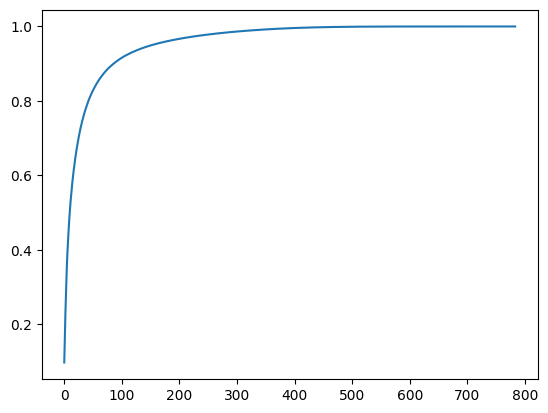

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))